# 04_01 Smoothing constants for Croston

Croston is run with fixed smoothing constants. This notebook selects them on a validation block that
ends before the first test origin, and then evaluates the selected values once on the 20 test origins
of the shared forecast design.

Croston has two smoothing constants:

- **alpha** smooths the positive demand size.
- **beta** smooths the interval between two positive demands.

Both are searched over 0.05 to 0.30 in steps of 0.05, crossed, which gives 36 combinations.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from numba import njit

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.benchmark.evaluation import _create_assessed_origins, prepare_daily_rows
from src.models.benchmark.models import create_history_features

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 120)

GRID = [round(float(value), 2) for value in np.arange(0.05, 0.301, 0.05)]
PAIRS = [(alpha, beta) for alpha in GRID for beta in GRID]
DEFAULT_PAIR = (0.1, 0.1)
BIAS_LIMIT = 0.10

## Evaluation design

The test block is the shared forecast design: 20 weekly Monday origins from 2026-03-02, each with a
seven-day horizon, and a series is assessed at an origin only after 28 observed/open days.

The validation block repeats that design with the same spacing, horizon and maturity rule, but ends
before the first test origin. Its last horizon closes one day before the test period starts, so no
observation used for parameter selection appears in the test evaluation.

In [2]:
DESIGN = load_benchmark_design()
VALIDATION_DESIGN = replace(
    DESIGN,
    first_origin=DESIGN.first_origin
    - pd.Timedelta(days=DESIGN.max_origins * DESIGN.origin_spacing_days),
)

con = duckdb.connect()
con.execute('PRAGMA threads=4')
audit = prepare_daily_rows(con, data_dir=DESIGN.data_dir)
create_history_features(con)

LAST_OBSERVED = pd.Timestamp(audit.loc[0, 'last_date'])
TEST_ORIGINS = DESIGN.origins_through(LAST_OBSERVED)
VALIDATION_ORIGINS = VALIDATION_DESIGN.origins_through(
    DESIGN.first_origin - pd.Timedelta(days=1)
)

print(f'Observed data: {audit.loc[0, "first_date"]} to {audit.loc[0, "last_date"]}')
print(
    f'Validation origins: {len(VALIDATION_ORIGINS)} '
    f'({VALIDATION_ORIGINS.min():%Y-%m-%d} to {VALIDATION_ORIGINS.max():%Y-%m-%d}, '
    f'last horizon ends {VALIDATION_ORIGINS.max() + pd.Timedelta(days=DESIGN.forecast_horizon_days - 1):%Y-%m-%d})'
)
print(
    f'Test origins: {len(TEST_ORIGINS)} '
    f'({TEST_ORIGINS.min():%Y-%m-%d} to {TEST_ORIGINS.max():%Y-%m-%d})'
)
assert VALIDATION_ORIGINS.max() + pd.Timedelta(days=DESIGN.forecast_horizon_days) <= TEST_ORIGINS.min()

Observed data: 2023-07-22 00:00:00 to 2026-07-21 00:00:00
Validation origins: 20 (2025-10-13 to 2026-02-23, last horizon ends 2026-03-01)
Test origins: 20 (2026-03-02 to 2026-07-13)


## Model and metrics

`_croston_levels` returns one constant daily rate per series, estimated only from observations
strictly before the origin: the smoothed positive demand size divided by the smoothed interval
between positive demands. Both states are updated after a positive demand only.

`_score` accumulates the metric sums over the active target rows, which are the same rows the
benchmark notebooks evaluate:

- `WAPE = sum(abs(forecast - actual)) / sum(actual)`
- `bias = (sum(forecast) - sum(actual)) / sum(actual)`

In [3]:
@njit
def _croston_levels(values, offsets, alpha, beta):
    out = np.zeros(len(offsets) - 1, dtype=np.float64)
    for group in range(len(offsets) - 1):
        start = offsets[group]
        end = offsets[group + 1]
        if start == end:
            continue
        size = 0.0
        interval = 0.0
        previous_positive = -1
        has_positive = False
        for position in range(start, end):
            value = values[position]
            relative_position = position - start
            if value > 0:
                if not has_positive:
                    size = value
                    interval = relative_position + 1.0
                    has_positive = True
                else:
                    size = alpha * value + (1.0 - alpha) * size
                    new_interval = relative_position - previous_positive
                    interval = beta * new_interval + (1.0 - beta) * interval
                previous_positive = relative_position
        out[group] = max(size / interval if interval > 0 else size, 0.0)
    return out


@njit
def _score(levels, actuals, offsets):
    abs_error = 0.0
    forecast = 0.0
    actual = 0.0
    for group in range(len(offsets) - 1):
        level = levels[group]
        for position in range(offsets[group], offsets[group + 1]):
            value = actuals[position]
            abs_error += abs(level - value)
            forecast += level
            actual += value
    return abs_error, forecast, actual


def _flatten(lists):
    arrays = [np.asarray(values, dtype=np.float64) for values in lists]
    lengths = np.fromiter((len(values) for values in arrays), dtype=np.int64, count=len(arrays))
    offsets = np.empty(len(arrays) + 1, dtype=np.int64)
    offsets[0] = 0
    np.cumsum(lengths, out=offsets[1:])
    flat = np.concatenate(arrays) if arrays else np.empty(0, dtype=np.float64)
    return np.maximum(np.nan_to_num(flat, nan=0.0), 0.0), offsets

## Rolling-origin evaluation over the parameter grid

Histories and target rows are read once per origin and reused for every parameter pair, so the grid
costs one database pass per origin instead of one per combination.

In [4]:
def _origin_arrays(origin):
    """Return aligned history and active-target arrays for one origin."""
    histories = con.execute(
        '''
        SELECT e.ARTIKEL_ID, e.MARKT_ID, LIST(d.demand ORDER BY d.period) AS history
        FROM benchmark_assessed_origins AS e
        INNER JOIN benchmark_daily_rows AS d
            ON d.ARTIKEL_ID = e.ARTIKEL_ID AND d.MARKT_ID = e.MARKT_ID AND d.period < e.origin
        WHERE e.origin = ?
        GROUP BY e.ARTIKEL_ID, e.MARKT_ID
        ''',
        [pd.Timestamp(origin).date()],
    ).fetchdf()
    targets = con.execute(
        '''
        SELECT e.ARTIKEL_ID, e.MARKT_ID, LIST(t.demand ORDER BY t.period) AS actuals
        FROM benchmark_assessed_origins AS e
        INNER JOIN benchmark_daily_rows AS t
            ON t.ARTIKEL_ID = e.ARTIKEL_ID AND t.MARKT_ID = e.MARKT_ID
            AND t.period >= e.origin AND t.period < e.origin + ? * INTERVAL 1 DAY
        WHERE e.origin = ? AND t.is_active
        GROUP BY e.ARTIKEL_ID, e.MARKT_ID
        ''',
        [int(DESIGN.forecast_horizon_days), pd.Timestamp(origin).date()],
    ).fetchdf()
    aligned = histories.merge(targets, on=['ARTIKEL_ID', 'MARKT_ID'], how='inner', validate='1:1')
    history_flat, history_offsets = _flatten(aligned['history'].tolist())
    actual_flat, actual_offsets = _flatten(aligned['actuals'].tolist())
    return history_flat, history_offsets, actual_flat, actual_offsets


def evaluate(origins, pairs):
    """Pool WAPE and bias over all origins for every parameter pair."""
    _create_assessed_origins(con, origins, DESIGN)
    totals = {pair: np.zeros(3) for pair in pairs}
    for origin in origins:
        history_flat, history_offsets, actual_flat, actual_offsets = _origin_arrays(origin)
        for pair in pairs:
            levels = _croston_levels(history_flat, history_offsets, *pair)
            totals[pair] += _score(levels, actual_flat, actual_offsets)
    rows = [
        {
            'alpha': alpha,
            'beta': beta,
            'wape': abs_error / actual,
            'bias': (forecast - actual) / actual,
            'actual_kg': actual,
        }
        for (alpha, beta), (abs_error, forecast, actual) in totals.items()
    ]
    return pd.DataFrame(rows)

## Validation grid

In [5]:
validation = evaluate(VALIDATION_ORIGINS, PAIRS)
print(f'{len(PAIRS)} parameter pairs, {len(VALIDATION_ORIGINS)} validation origins')
display(
    validation.sort_values('wape').head(5)
    .style.format({'wape': '{:.2%}', 'bias': '{:+.2%}', 'actual_kg': '{:,.0f}'})
    .hide(axis='index')
)

36 parameter pairs, 20 validation origins


alpha,beta,wape,bias,actual_kg
0.050000,0.050000,106.15%,-10.93%,"2,721,105"
0.100000,0.050000,107.77%,-11.77%,"2,721,105"
0.050000,0.100000,107.86%,-7.53%,"2,721,105"
0.150000,0.050000,109.34%,-12.22%,"2,721,105"
0.100000,0.100000,109.81%,-8.05%,"2,721,105"


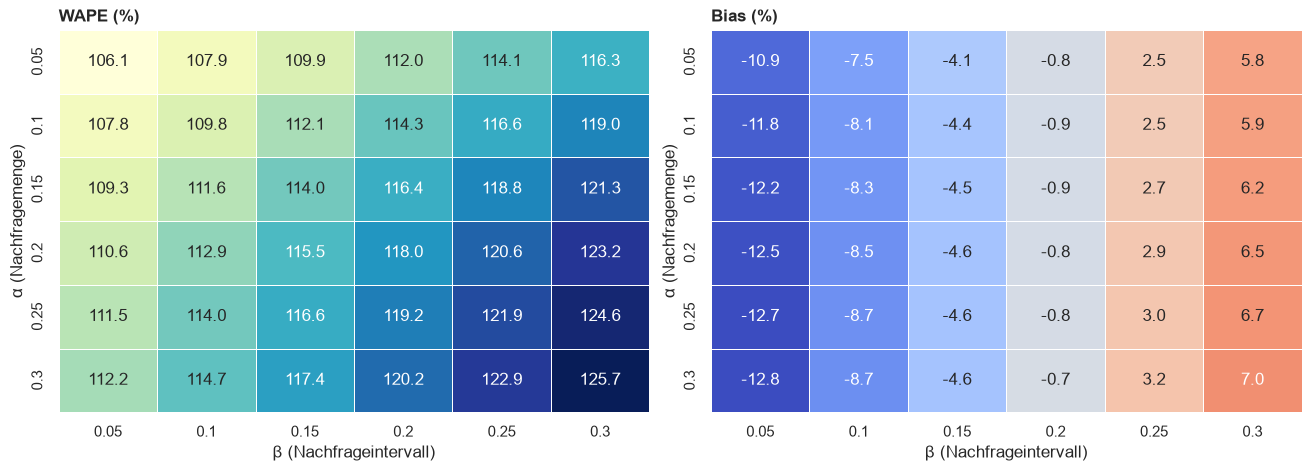

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for ax, (column, title, cmap) in zip(
    axes,
    [('wape', 'WAPE (%)', 'YlGnBu'), ('bias', 'Bias (%)', 'coolwarm')],
):
    grid = validation.pivot(index='alpha', columns='beta', values=column)
    sns.heatmap(
        100 * grid, ax=ax, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5,
        center=0 if column == 'bias' else None, cbar=False, 
    )
    ax.set_title(title, loc='left', weight='bold')
    ax.set_xlabel('β (Nachfrageintervall)')
    ax.set_ylabel('α (Nachfragemenge)')
plt.show()

## Selection

WAPE alone rewards small forecasts on intermittent series, because a forecast of zero already
reaches 100 % WAPE. The lowest-WAPE pair is therefore only accepted when its pooled bias stays
within ±10 %. Otherwise the pair with the smallest absolute bias is used.

In [7]:
feasible = validation.loc[validation.bias.abs().le(BIAS_LIMIT)]
if feasible.empty:
    print(f'No pair stays inside +/-{BIAS_LIMIT:.0%} bias; falling back to the smallest absolute bias.')
    selected = validation.assign(abs_bias=validation.bias.abs()).sort_values('abs_bias').iloc[0]
else:
    selected = feasible.sort_values('wape').iloc[0]
unconstrained = validation.sort_values('wape').iloc[0]

print(
    f'Selected: alpha={selected.alpha:.2f}, beta={selected.beta:.2f} '
    f'-> validation WAPE {selected.wape:.2%}, bias {selected.bias:+.2%}\n'
    f'Lowest WAPE without the bias limit: alpha={unconstrained.alpha:.2f}, beta={unconstrained.beta:.2f} '
    f'-> {unconstrained.wape:.2%}, bias {unconstrained.bias:+.2%}'
)

Selected: alpha=0.05, beta=0.10 -> validation WAPE 107.86%, bias -7.53%
Lowest WAPE without the bias limit: alpha=0.05, beta=0.05 -> 106.15%, bias -10.93%


## Test evaluation

The selected pair and the current default of `alpha = beta = 0.1` are evaluated once on the 20 test
origins. No further selection happens here.

In [8]:
selected_pair = (float(selected.alpha), float(selected.beta))
test = evaluate(TEST_ORIGINS, sorted({selected_pair, DEFAULT_PAIR})).set_index(['alpha', 'beta'])
display(test.style.format({'wape': '{:.2%}', 'bias': '{:+.2%}', 'actual_kg': '{:,.0f}'}))

tuned = test.loc[selected_pair]
default = test.loc[DEFAULT_PAIR]
delta_pp = 100 * (tuned.wape - default.wape)
print(
    f'Croston with alpha={selected_pair[0]:.2f}, beta={selected_pair[1]:.2f}: '
    f'{tuned.wape:.2%} WAPE, bias {tuned.bias:+.2%}\n'
    f'Croston with the 0.1 default: {default.wape:.2%} WAPE, bias {default.bias:+.2%}\n'
    f'Difference: {delta_pp:+.2f} percentage points'
)

,,wape,bias,actual_kg
alpha,beta,,,
0.050000,0.100000,105.14%,-7.43%,"2,661,595"
0.100000,0.100000,106.82%,-6.89%,"2,661,595"


Croston with alpha=0.05, beta=0.10: 105.14% WAPE, bias -7.43%
Croston with the 0.1 default: 106.82% WAPE, bias -6.89%
Difference: -1.68 percentage points
